# Basic demonstration of fUSi analysis

This notebook shows the basic demonstration of analyzing audio data collected at UCLA


In [35]:
%load_ext autoreload
%autoreload 2

# import nilearn as nl
from nilearn import image
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

import nibabel as nib

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from ucla_doc_utils import DirectoryManager
import ucla_fusi_utils_audio as utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
base_path=Path('/Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-12')
sequence='seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops'

smoothing_fwhm=.5 #0 spatial smoothing in mm to apply to the data before computing GLM
behavior_offset = 1 # in seconds

dm = DirectoryManager(base_path, sequence)
dm.list_acquisition_directories()
dm.print_paths()

/Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops/fUSI
Directories in acquisitions path:
    seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops
List of all directories in acquisitions path:
    log_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/logs/task_1.log
    task_event_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/streams/task_1-event_stream.h5
    probe_event_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/streams/probe_1-event_stream.h5
    sequence_data_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops
    raw_data_path: /Volumes/192.168.1.169/UCLA_collaboration/2024

In [41]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'

print(beamform_command)
print(power_doppler_command)

python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops"
python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/192.168.1.169/UCLA_collaboration/2024-06-07/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops"


In [42]:
# load probe and task events
probe_events=utils.extract_probe_events(dm.probe_event_file_path)

# process power doppler files
fusi_data, probe_events = utils.process_power_doppler_files(dm.power_doppler_path, 60, probe_events)

# process task events
task_events = utils.extract_task_events(dm.task_event_file_path)
task_events.onset=task_events.onset + behavior_offset
print(task_events)

Filtered filenames: ['ensemble_2024-06-07T23-05-31-185361-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-33-211359-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-34-897396-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-36-509809-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-38-117037-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-39-731457-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-41-329079-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-06-07T23-05-42-962924-pixel_size_wavelengths=0.

Convert the pandas data structure into something importable to nilearn

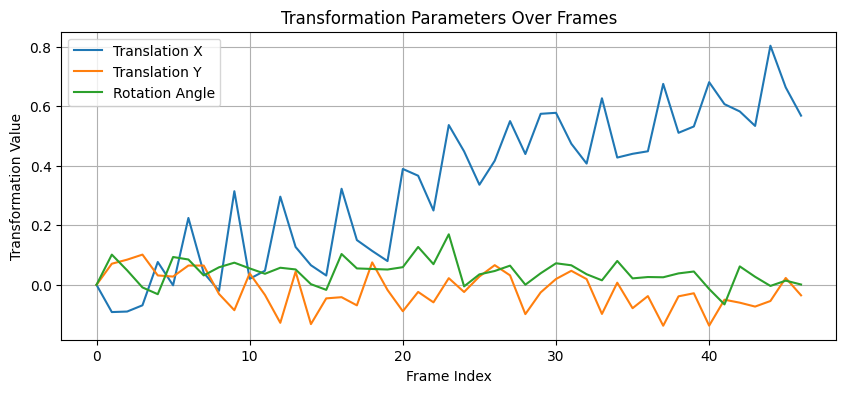

In [43]:
# Perform image registration and display transformation dynamic

apply_image_registration = True # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
plot_transformations=True


fusi_data_3d = fusi_data[:, 0, :, :]  # Keep only the first index of the second dimension
fusi_data_3d_reg,transformations=utils.register_ants(fusi_data_3d)
fusi_data_3d_reg_expanded = np.expand_dims(fusi_data_3d_reg, axis=1)  # Add a singleton dimension at axis 1
if apply_image_registration:
    fusi_data = np.tile(fusi_data_3d_reg_expanded, (1, 2, 1, 1))

if plot_transformations:
    plt.figure(figsize=(10, 4))
    plt.plot(transformations[0, :], label='Translation X')
    plt.plot(transformations[1, :], label='Translation Y')
    plt.plot(transformations[2, :]*180/np.pi, label='Rotation Angle')
    plt.title('Transformation Parameters Over Frames')
    plt.xlabel('Frame Index')
    plt.ylabel('Transformation Value')
    plt.legend()
    plt.grid(True)
    plt.show()

(3, 100)


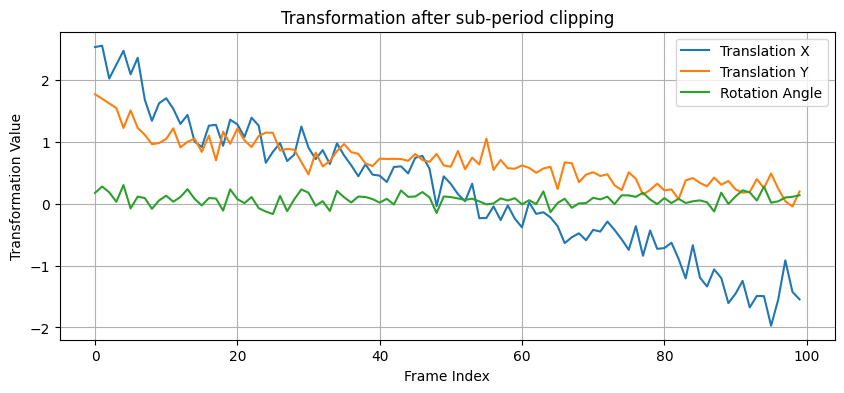

In [24]:
###############################################################################################
#     Depending on the transformation matrix, we can select a sub-period of time to study     #
###############################################################################################

study_sub_period = True
sub_period_to_study = [10, 110]

if study_sub_period:
    # Sub-period of fusi_data
    fusi_data_sub_period = fusi_data[:, :, :, sub_period_to_study[0]:sub_period_to_study[1]]
    # print(fusi_data_sub_period.shape)

    # Sub-period of probe_events
    probe_events.reset_index(drop=True, inplace=True)
    probe_events_sub_period = probe_events.iloc[sub_period_to_study[0]:sub_period_to_study[1], :].reset_index(drop=True)
    # print(probe_events_sub_period)

    # Sub-period of task events
    last_valid_index = -1
    for n in range(len(task_events)):
        if task_events.iloc[n]['onset'] + task_events.iloc[n]['duration'] > probe_events_sub_period.iloc[-1]['time_stamp']:
            last_valid_index = n - 1
            break
    # If no valid index is found, use all events; otherwise, slice up to the last valid index and reset index
    if last_valid_index == -1:
        task_events_sub = task_events.copy().reset_index(drop=True)
    else:
        task_events_sub = task_events.iloc[:last_valid_index + 1].reset_index(drop=True)
    # print(task_events_sub.shape)

    # Sub-period of transformations
    transformations_sub_period = transformations[:, sub_period_to_study[0]:sub_period_to_study[1]]
    print(transformations_sub_period.shape)

    plt.figure(figsize=(10, 4))
    plt.plot(transformations_sub_period[0, :], label='Translation X')
    plt.plot(transformations_sub_period[1, :], label='Translation Y')
    plt.plot(transformations_sub_period[2, :]*180/np.pi, label='Rotation Angle')
    plt.title('Transformation after sub-period clipping')
    plt.xlabel('Frame Index')
    plt.ylabel('Transformation Value')
    plt.legend()
    plt.grid(True)
    plt.show()

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_8717/3970846581.py:33: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



<Figure size 640x480 with 0 Axes>

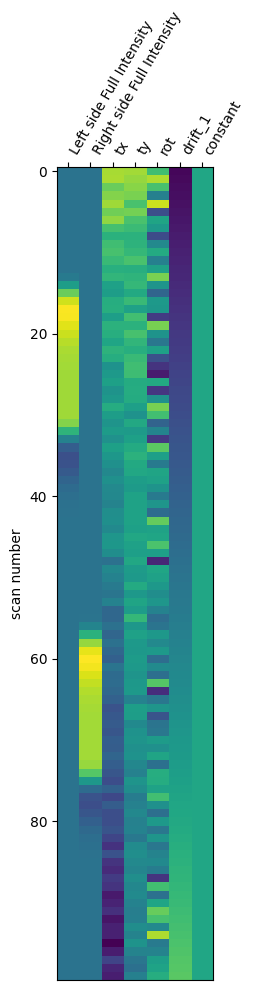

In [25]:
#######################################
#     Create design matrix for GLM    #
#######################################

if study_sub_period:
    fusi_data=fusi_data_sub_period
    probe_events=probe_events_sub_period
    task_events=task_events_sub
    transformations=transformations_sub_period

hrf_model = "glover"
if apply_image_registration:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=transformations.transpose(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

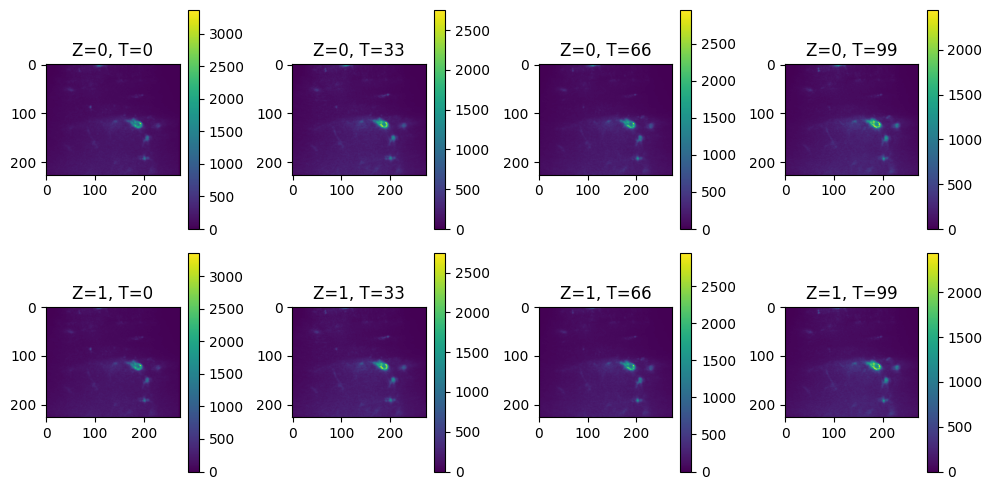

In [26]:
# Plot the data, make sure nothing crazy is happening, in particular, as I am mocking a 3D scan to play nice with nilearn, we need to make sure the data is in the right shape and the info across the second dimension is simply a copy
import matplotlib.pyplot as plt
# visualize to ensure we are getting what we think we should be getting!

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))  # 2 rows for Z dimension, 4 columns for T dimension
for z_dim in range(2):  # Loop over the Z dimension (1 dimension)
    for t_index, t_dim in enumerate(np.linspace(0, fusi_data.shape[3] - 1, 4, dtype=int)):  # Sample 4 equally spaced indices along the T dimension
        ax = axs[z_dim, t_index]
        img_plot = ax.imshow(np.flip(fusi_data[:, z_dim, :, t_dim].transpose(), axis=0), aspect='equal')
        ax.set_title(f'Z={z_dim}, T={t_dim}')
        plt.colorbar(img_plot, ax=ax)

plt.tight_layout()
plt.show()

In [27]:
from nilearn.signal import butterworth

affine=np.diag([.15,.15,.15,0])
# pd=np.array(fusi_data)
def boxcar_smooth(data, window_size):
    if window_size>0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    else:
        smoothed_data=data
    return smoothed_data

window_size = 5 # Number of time points for smoothing
pd = boxcar_smooth(fusi_data, window_size)
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data.shape

(274, 2, 226, 100)

In [28]:
# This cell creates an identity matrix of size equal to the number of columns in the design_matrix.
# It then constructs a dictionary named 'basic_contrasts' where each key is a column name from the design_matrix
# and the corresponding value is a row from the identity matrix. This effectively sets up basic contrasts
# for each experimental condition represented in the design_matrix.

contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
basic_contrasts

{'Left side Full Intensity': array([1., 0., 0., 0., 0., 0., 0.]),
 'Right side Full Intensity': array([0., 1., 0., 0., 0., 0., 0.]),
 'tx': array([0., 0., 1., 0., 0., 0., 0.]),
 'ty': array([0., 0., 0., 1., 0., 0., 0.]),
 'rot': array([0., 0., 0., 0., 1., 0., 0.]),
 'drift_1': array([0., 0., 0., 0., 0., 1., 0.]),
 'constant': array([0., 0., 0., 0., 0., 0., 1.])}

In [29]:
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/glm/first_level/first_level.py:707: UserWarning:

Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected



Computing contrasts
	contrast id: Left side Full Intensity


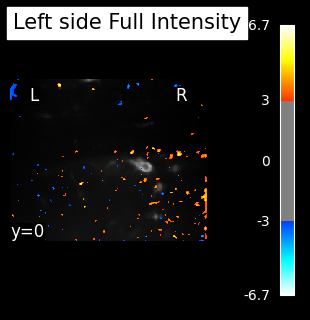

	contrast id: Right side Full Intensity


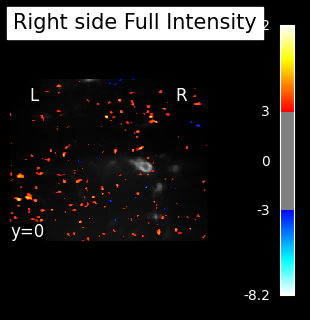

	contrast id: tx


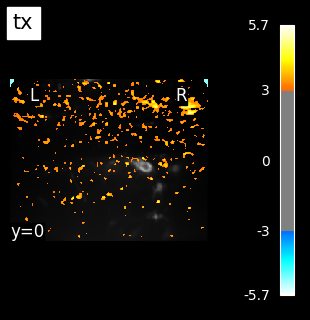

	contrast id: ty


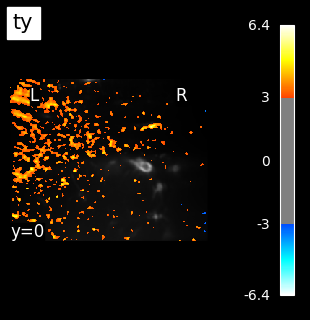

	contrast id: rot


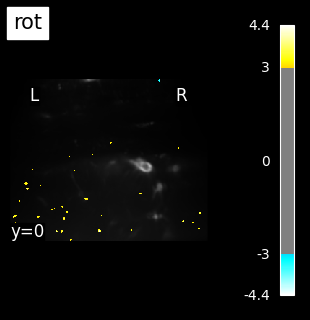

	contrast id: drift_1


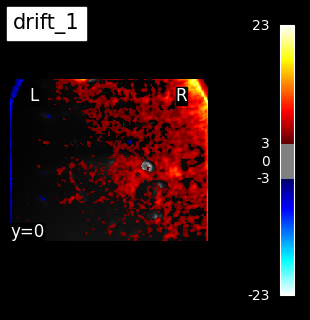

	contrast id: constant


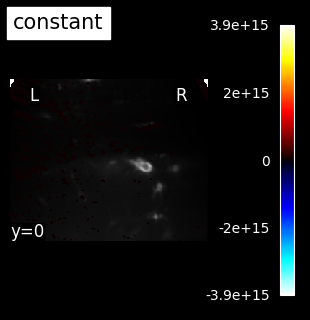

In [30]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img

print("Computing contrasts")

mean_image = mean_img(nifti_data)
# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat") # 
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.0 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold= 3.0,        
        cut_coords=[0],
        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



Processing contrast: Left side Full Intensity
Processing contrast: Right side Full Intensity


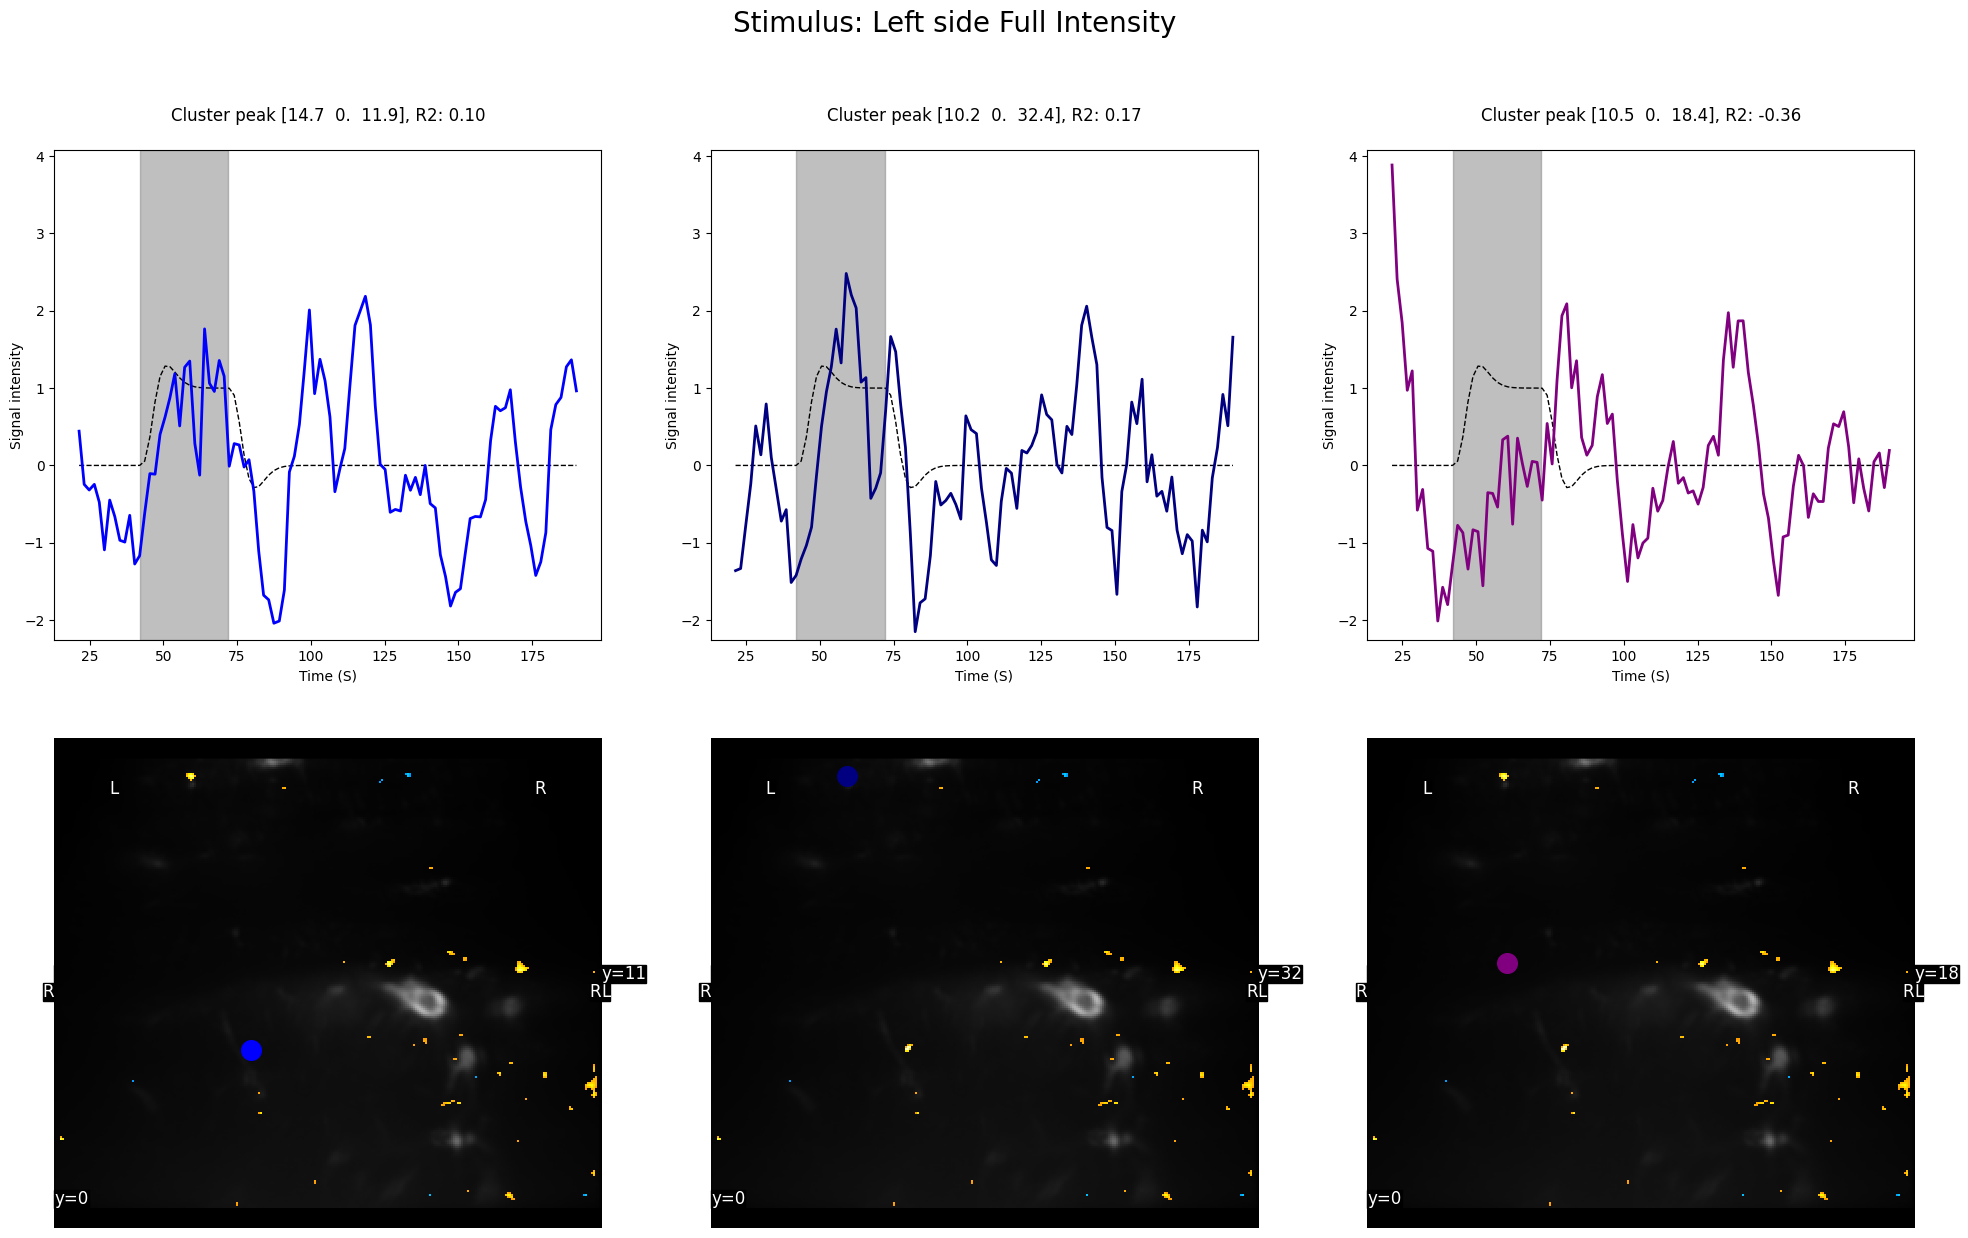

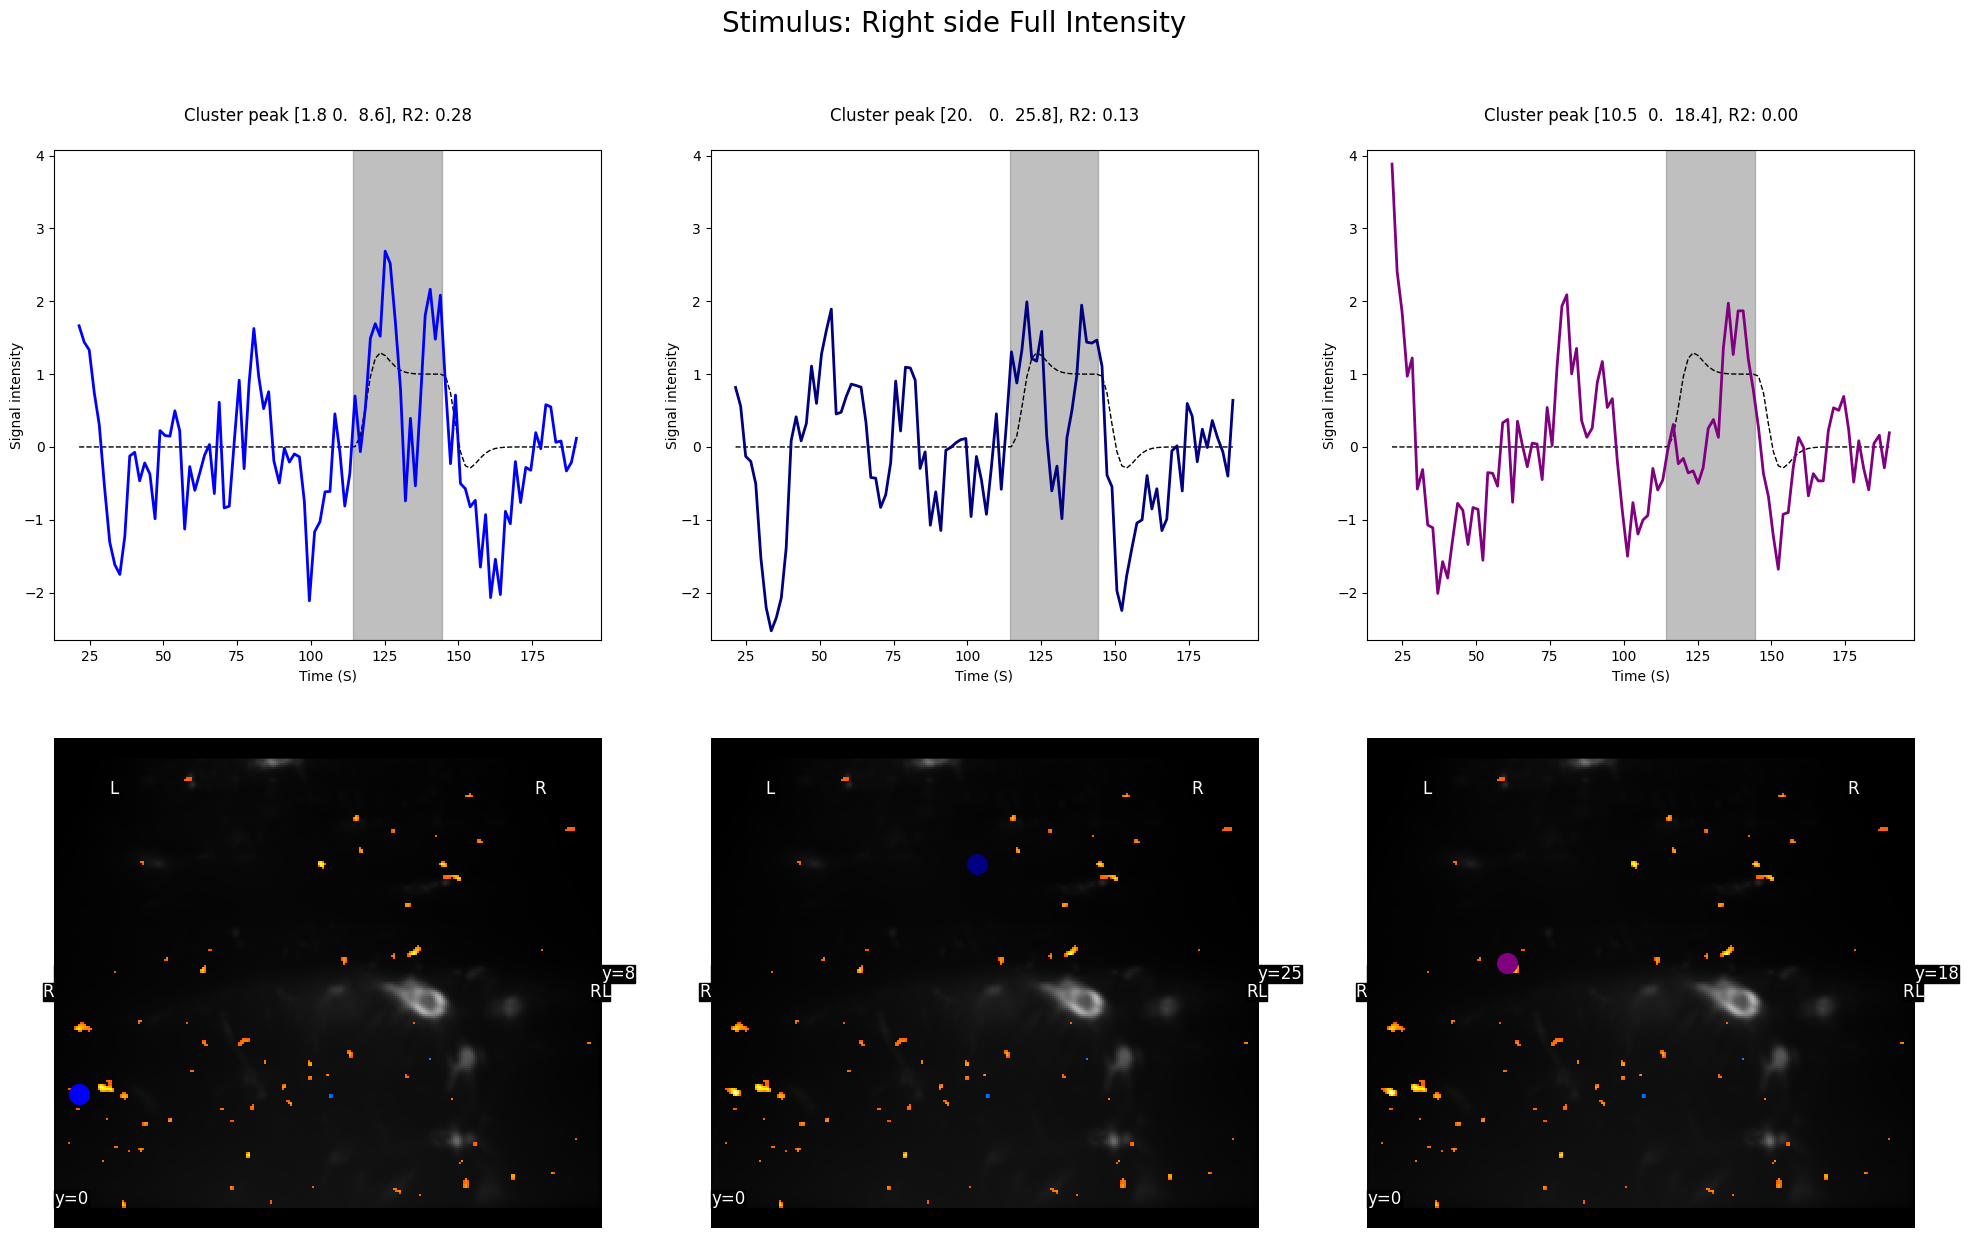

In [31]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table
import numpy as np

stat_threshold = 1
num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)

# Loop over all conditions in basic_contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    if contrast_id not in ['drift_1', 'constant','tx','ty','rot']:
        print(f"Processing contrast: {contrast_id}")
        z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
        table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
        table.set_index("Cluster ID", drop=True)

        if not table.empty and len(table) >= num_locations:
            # get the num_locations largest clusters' max x, y, and z coordinates
            coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
            coords = np.vstack([coords, [10.45000061, 0., 18.40000045]])

            # Now use the ROIs to extract the time series 
            masker = NiftiSpheresMasker(
                coords,
                radius=0.1,  # specifies the size of the spherical region around each given coordinate from which the signal will be extracted
                detrend=True,
                standardize="zscore",  # zscore psc
                t_r=3.5,
                memory_level=1,
                verbose=0,
            )
            real_timeseries = masker.fit_transform(nifti_data)
            predicted_timeseries = np.tile(design_matrix[contrast_id].values, (real_timeseries.shape[1], 1)).T

            from sklearn.metrics import r2_score

            # Calculate the R-squared value for each ROI
            r_squared_values = []
            for i in range(real_timeseries.shape[1]):
                r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
                r_squared_values.append(r_squared)
            
            # Plotting the time series for each ROI and the corresponding location of each ROI
            colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
            N = real_timeseries.shape[-1]
            fig1, axs1 = plt.subplots(2, N)
            fig1.suptitle(f"Stimulus: {contrast_id}", fontsize=20)  # Set the title of the figure with a bigger font size
            # get plot limits, common across all axis
            mx = real_timeseries.max() + 0.05 * real_timeseries.max()
            mn = real_timeseries.min() + 0.05 * real_timeseries.min()

            for i in range(N):
                # plotting time series
                axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
                if masker.standardize != "psc":
                    axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)

                axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)

                axs1[0, i].set_xlabel("Time (S)")

                if masker.standardize == "psc":
                    axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
                else:
                    axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

                # plotting image below the time series
                for index, row in task_events.iterrows():
                    if row['trial_type'] == contrast_id:
                        axs1[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)

                roi_img = plotting.plot_stat_map(
                    z_map,
                    cut_coords=coords[i],
                    threshold=4,
                    figure=fig1,
                    axes=axs1[1, i],
                    display_mode="y",
                    colorbar=False,
                    bg_img=mean_image,
                )

                axs1[0, i].set_ylim(mn, mx)
                roi_img.add_markers([coords[i]], colors[i], 200)
            fig1.set_size_inches(24, 14)
        else:
            print(f"No valid clusters found for {contrast_id} that meet the criteria.")

In [32]:
# from nilearn.maskers import NiftiSpheresMasker
# from nilearn.reporting import get_clusters_table

# # Find ROIs by identifying the locations that show a significant response to the stimulus
# mean_image = mean_img(nifti_data)

# # Compute contrasts for each condition in basic_contrasts and store the statistical maps
# # Exclude 'drift_1','constant','tx','ty','rot' from the conditions to be processed
# z_maps = {contrast_id: fmri_glm.compute_contrast(contrast_val, output_type="stat") 
#           for contrast_id, contrast_val in basic_contrasts.items() 
#           if contrast_id not in ['drift_1', 'constant','tx','ty','rot']}

# # Create a dictionary to store the tables for each condition
# tables = {}

# # Iterate over each condition to create selected_z_map and corresponding table
# for condition, z_map in z_maps.items():
#     print(f"Processing condition: {condition}")
#     table = get_clusters_table(z_map, stat_threshold=1.1, cluster_threshold=20) # cluster_threshold = number of voxels in a cluster
#     table.set_index("Cluster ID", drop=True)
#     tables[condition] = table

# condition_index = 0
# for condition, table in tables.items():
#     # get the 3 largest clusters' max x, y, and z coordinates
#     coords = table.loc[range(0, 3), ["X", "Y", "Z"]].values

#     masker = NiftiSpheresMasker(
#         coords,
#         radius=.5,
#         detrend=True,
#         standardize="zscore_sample",
#         t_r=3.5,
#         memory="nilearn_cache",
#         memory_level=1,
#         verbose=0,
#     )

#     real_timeseries = masker.fit_transform(nifti_data)
#     predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])

In [33]:
# from nilearn.maskers import NiftiSpheresMasker
# from nilearn.reporting import get_clusters_table

# contrast_to_plot = 'left_hand_squeeze'
# stat_threshold = 4
# num_locations = 2 # How many ROIs to visualize. An additional random ROI will be added

# # Find ROIs by identifying the locations that show a significant response to the stimulus
# mean_image = mean_img(nifti_data)
# z_map = fmri_glm.compute_contrast(basic_contrasts[contrast_to_plot], output_type="stat")
# table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20) # minimum cluster size to be considered
# table.set_index("Cluster ID", drop=True)
# table.head()

# # get the num_locations largest clusters' max x, y, and z coordinates
# coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
# coords = np.vstack([coords, [10.45000061,  0.        , 18.40000045]])

# # Now use the ROIs to extract the time series 
# masker = NiftiSpheresMasker(coords)
# standardize="zscore" # zscore psc
# masker = NiftiSpheresMasker(
#     coords,
#     radius= 0.1, #  specifies the size of the spherical region around each given coordinate from which the signal will be extracted
#     detrend=True,
#     standardize=standardize, # zscore psc
#     t_r=3.5,
#     memory_level=1,
#     verbose=0,
# )
# real_timeseries = masker.fit_transform(nifti_data)
# predicted_timeseries = np.tile(design_matrix[contrast_to_plot].values, (real_timeseries.shape[1], 1)).T

# from sklearn.metrics import r2_score

# # Calculate the R-squared value for each ROI
# r_squared_values = []
# for i in range(real_timeseries.shape[1]):
#     r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
#     r_squared_values.append(r_squared)


In [34]:
# # And finaly, plot the time series for each ROI and the corresponding location of each ROI
# # colors for each of the clusters
# colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# # plot the time series and corresponding locations
# N=real_timeseries.shape[-1]
# fig1, axs1 = plt.subplots(2, N)

# # get plot limits, common across all axis
# mx=real_timeseries.max()+0.05*real_timeseries.max()
# mn=real_timeseries.min()+0.05*real_timeseries.min()

# for i in range(N):
#     # plotting time series
#     axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
#     if masker.standardize != "psc":
#         axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)

#     axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)

#     axs1[0, i].set_xlabel("Time (S)")

#     if masker.standardize == "psc":
#         axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
#     else:
#         axs1[0, i].set_ylabel("Signal intensity", labelpad=0)
    

#     # plotting image below the time series
#     for onset, duration in zip(task_events['onset'], task_events['duration']):
#         axs1[0, i].axvspan(onset+behavior_offset, onset + duration+behavior_offset, color='gray', alpha=0.5)
    
#     roi_img = plotting.plot_stat_map(
#         z_map,
#         cut_coords=coords[i],
#         threshold= 4,
#         figure=fig1,
#         axes=axs1[1, i],
#         display_mode="y",
#         colorbar=False,
#         bg_img=mean_image,
#     )
    
#     axs1[0, i].set_ylim(mn, mx)
#     roi_img.add_markers([coords[i]], colors[i], 200)
# fig1.set_size_inches(24, 14)

